# NB11 — Zero-Trust Routing (CDTS Component e)

**The thesis payoff.** The unifying result (§8) proved competence is the single factor governing
trust failures, and (d) showed competence is estimable label-free. So the routing claim:
**abstain on low competence, not low confidence** -- because low-competence detectors are
*confidently wrong* (the calibration-failure story), so confidence is the wrong thing to route on.

**Selective prediction / risk-coverage.** At coverage c we answer the c fraction we most trust
and abstain on the rest; we measure error on the answered set. A good routing signal rejects the
cases the detector gets wrong. Lower risk-coverage curve = better. Metric: AURC (area under
risk-coverage, lower better) + selective error at fixed coverage.

**Three routing signals (honest framings):**
- (A) BASELINE -- per-frame confidence |prob_fake - 0.5| (standard selective prediction).
- (B) PER-FRAME COMPETENCE (deployable) -- per-frame label-free proxy (entropy / divergence of
  the frame's own score from the reference), no generator identity used.
- (C) PER-BATCH COMPETENCE (demonstration) -- estimate competence from a source-batch's score
  distribution (ks_vs_ref of the batch), route whole batches. Realistic monitoring; generator
  identity NOT used, only the batch's empirical distribution (computable in deployment).

**Honesty note baked in:** (C) does NOT look up per-known-generator labels; it computes the
batch's divergence from the reference, which a deployer genuinely can. (B) is fully per-frame.


## Cell 1 — Setup + pool all scored frames

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os, sys, glob, subprocess
import pandas as pd, numpy as np
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
PARENT = "/content/drive/MyDrive/CDTS_Research"
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"{PARENT}/{f}"): subprocess.run(f'cp "{PARENT}/{f}" /root/{f}', shell=True)
subprocess.run("git config --global credential.helper store", shell=True)

# pool all DF40 scored frames; tag each with its source generator
tl = pd.read_csv(f"{REPO}/reports/calibration/timeline_df40_xceptionFS.csv")
frames = []
for f in sorted(glob.glob(f"{REPO}/reports/scores/xceptionFS_df40_*.parquet")):
    method = os.path.basename(f).replace("xceptionFS_df40_","").replace(".parquet","")
    if method not in tl.method.values: continue
    s = pd.read_parquet(f)[['prob_fake','label']].copy()
    s['generator'] = method
    s['gen_AUC'] = float(tl[tl.method==method].AUC.iloc[0])
    frames.append(s)
pool = pd.concat(frames, ignore_index=True)
print(f"pooled frames: {len(pool)} across {pool.generator.nunique()} generators")
print(f"class balance: {pool.label.value_counts().to_dict()}")
print(f"overall accuracy @0.5: {((pool.prob_fake>0.5).astype(int)==pool.label).mean():.3f}")

Mounted at /content/drive
pooled frames: 593502 across 21 generators
class balance: {1: 475482, 0: 118020}
overall accuracy @0.5: 0.666


## Cell 2 — Reference distribution + per-frame competence proxies

Per-frame label-free signals (no generator identity): how far the frame's own score sits from the
known-competent reference (FF++ faceswap), and its prediction entropy.


In [2]:
import pandas as pd, numpy as np
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"

# reference: FF++ faceswap+real scores (known-competent in-domain)
ref = pd.read_parquet(f"{REPO}/reports/scores/xception_ffpp_test.parquet")
ref_scores = ref[(ref.method=='faceswap')|(ref.label==0)]['prob_fake'].values
ref_mean = ref_scores.mean(); ref_std = ref_scores.std()
print(f"reference: mean={ref_mean:.3f} std={ref_std:.3f}")

def binary_entropy(p):
    p = np.clip(p,1e-7,1-1e-7); return -p*np.log2(p)-(1-p)*np.log2(1-p)

# per-frame competence proxies (higher = LESS competent regime = should abstain)
pool['confidence'] = np.abs(pool['prob_fake']-0.5)           # higher=more confident (A: answer high)
pool['entropy'] = binary_entropy(pool['prob_fake'].values)    # higher=less confident
# per-frame distance from reference mean (a frame whose score is 'unusual' vs in-domain)
pool['ref_dist'] = np.abs(pool['prob_fake'] - ref_mean)
print("per-frame signals added:", ['confidence','entropy','ref_dist'])
print(pool[['prob_fake','confidence','entropy','ref_dist']].describe().round(3).to_string())

reference: mean=0.471 std=0.469
per-frame signals added: ['confidence', 'entropy', 'ref_dist']
        prob_fake  confidence     entropy    ref_dist
count  593502.000  593502.000  593502.000  593502.000
mean        0.619       0.420       0.279       0.427
std         0.421       0.122       0.323       0.128
min         0.000       0.000       0.000       0.000
25%         0.095       0.393       0.015       0.391
50%         0.880       0.484       0.119       0.470
75%         0.997       0.499       0.492       0.525
max         1.000       0.500       1.000       0.529


## Cell 3 — Per-batch competence signal (ks_vs_ref of each source-batch)

Treat each generator's frames as a deployment 'batch/source'. Compute the batch's score-
distribution divergence from the reference (ks_vs_ref) -- a deployer can compute this without
knowing the generator. Lower competence regime -> higher divergence -> route batch to review.


In [3]:
import pandas as pd, numpy as np
from scipy.stats import ks_2samp
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
ref = pd.read_parquet(f"{REPO}/reports/scores/xception_ffpp_test.parquet")
ref_scores = ref[(ref.method=='faceswap')|(ref.label==0)]['prob_fake'].values

# per-batch (=per-generator here) competence signal from the batch's OWN scores
batch_sig = {}
for g, grp in pool.groupby('generator'):
    ks = ks_2samp(grp['prob_fake'].values, ref_scores).statistic
    batch_sig[g] = ks
pool['batch_ks'] = pool['generator'].map(batch_sig)
# higher batch_ks = MORE like reference = MORE competent (from NB09: ks_vs_ref +0.95 with AUC)
# so for routing: answer high batch_ks, abstain low batch_ks
print("per-batch competence signal (ks_vs_ref) vs true AUC:")
chk = pool.groupby('generator').agg(batch_ks=('batch_ks','first'), AUC=('gen_AUC','first'))
from scipy.stats import pearsonr
r,p = pearsonr(chk.batch_ks, chk.AUC)
print(chk.sort_values('AUC').round(3).to_string())
print(f"\nbatch_ks vs AUC: r={r:.3f} (confirms batch signal tracks competence, label-free)")

per-batch competence signal (ks_vs_ref) vs true AUC:
             batch_ks    AUC
generator                   
sadtalker       0.197  0.427
pixart          0.224  0.433
wav2lip         0.171  0.470
DiT             0.206  0.521
SiT             0.223  0.554
lia             0.232  0.607
StyleGANXL      0.301  0.637
StyleGAN2       0.275  0.649
StyleGAN3       0.278  0.679
sd2.1           0.292  0.688
pirender        0.299  0.688
rddm            0.348  0.733
ddim            0.314  0.766
fomm            0.334  0.801
inswap          0.309  0.815
facevid2vid     0.330  0.822
faceswap        0.369  0.892
fsgan           0.346  0.900
facedancer      0.376  0.933
blendface       0.404  0.943
simswap         0.409  0.948

batch_ks vs AUC: r=0.952 (confirms batch signal tracks competence, label-free)


## Cell 4 — Risk-coverage comparison (the core experiment)

At each coverage c: answer the top-c fraction by the routing score, abstain on the rest, measure
error on answered. Compare: (A) confidence, (B) per-frame competence, (C) per-batch competence.


In [4]:
import pandas as pd, numpy as np
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"

pool['correct'] = ((pool['prob_fake']>0.5).astype(int)==pool['label']).astype(int)
pool['error'] = 1 - pool['correct']

def risk_coverage(df, routing_score, higher_is_answer=True):
    # sort so the MOST-trusted (highest routing_score if higher_is_answer) are answered first
    s = df[routing_score].values * (1 if higher_is_answer else -1)
    order = np.argsort(-s)  # answer highest first
    err = df['error'].values[order]
    coverages = np.arange(1, len(err)+1)/len(err)
    cum_err = np.cumsum(err)/np.arange(1, len(err)+1)  # selective error at each coverage
    return coverages, cum_err

# AURC = mean selective error over coverages (lower=better)
def aurc(cov, cum_err): return np.trapz(cum_err, cov)

configs = {
  '(A) confidence': ('confidence', True),
  '(B) per-frame competence (entropy)': ('entropy', False),   # lower entropy=answer
  '(B2) per-frame ref-dist': ('ref_dist', False),             # lower dist=answer
  '(C) per-batch competence (ks)': ('batch_ks', True),        # higher ks=answer
}
print("=== risk-coverage: AURC (lower=better) + selective error at fixed coverage ===")
print(f"{'routing signal':38s} {'AURC':>8s} {'err@70%':>9s} {'err@80%':>9s} {'err@90%':>9s}")
rows=[]
curves={}
for name,(sig,hia) in configs.items():
    cov,ce = risk_coverage(pool, sig, hia)
    curves[name]=(cov,ce)
    a = aurc(cov,ce)
    def err_at(c):
        idx=np.searchsorted(cov,c); return ce[min(idx,len(ce)-1)]
    rows.append({'routing':name,'AURC':a,'err70':err_at(0.7),'err80':err_at(0.8),'err90':err_at(0.9)})
    print(f"{name:38s} {a:8.4f} {err_at(0.7):9.4f} {err_at(0.8):9.4f} {err_at(0.9):9.4f}")

rc = pd.DataFrame(rows)
rc.to_csv(f"{REPO}/reports/calibration/routing_risk_coverage.csv", index=False)
# overall (no abstention) error for reference
print(f"\nfull-coverage error (no abstention): {pool['error'].mean():.4f}")
print("\nlower AURC = the signal rejects the wrong predictions better.")

=== risk-coverage: AURC (lower=better) + selective error at fixed coverage ===
routing signal                             AURC   err@70%   err@80%   err@90%
(A) confidence                           0.2208    0.2874    0.3025    0.3168
(B) per-frame competence (entropy)       0.2208    0.2874    0.3025    0.3168
(B2) per-frame ref-dist                  0.4738    0.4483    0.4058    0.3676
(C) per-batch competence (ks)            0.1907    0.2391    0.2792    0.3052

full-coverage error (no abstention): 0.3338

lower AURC = the signal rejects the wrong predictions better.


/tmp/ipykernel_4890/1377302265.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  def aurc(cov, cum_err): return np.trapz(cum_err, cov)


## Cell 5 — Risk-coverage figure + commit

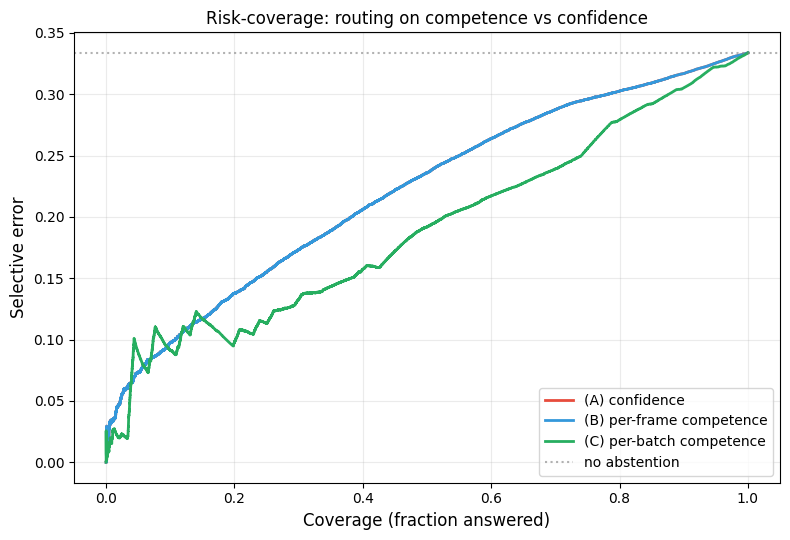

saved: /content/drive/MyDrive/CDTS_Research/deepfake-trust-research/figures/routing_risk_coverage.png


In [ ]:
import pandas as pd, numpy as np, os
import matplotlib.pyplot as plt
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"

pool['correct'] = ((pool['prob_fake']>0.5).astype(int)==pool['label']).astype(int)
pool['error'] = 1-pool['correct']
def risk_coverage(df, sig, hia=True):
    s=df[sig].values*(1 if hia else -1); order=np.argsort(-s)
    err=df['error'].values[order]
    return np.arange(1,len(err)+1)/len(err), np.cumsum(err)/np.arange(1,len(err)+1)

plt.figure(figsize=(8,5.5))
plots = [('(A) confidence','confidence',True,'#E74C3C'),
         ('(B) per-frame competence','entropy',False,'#3498DB'),
         ('(C) per-batch competence','batch_ks',True,'#27AE60')]
for name,sig,hia,c in plots:
    cov,ce = risk_coverage(pool,sig,hia)
    plt.plot(cov,ce,lw=2,color=c,label=name)
plt.axhline(pool['error'].mean(),color='gray',ls=':',alpha=0.6,label='no abstention')
plt.xlabel('Coverage (fraction answered)',fontsize=12)
plt.ylabel('Selective error',fontsize=12)
plt.title('Risk-coverage: routing on competence vs confidence',fontsize=12)
plt.legend(fontsize=10); plt.grid(alpha=0.25); plt.tight_layout()
out=f"{REPO}/figures/routing_risk_coverage.png"
plt.savefig(out,dpi=300,bbox_inches='tight'); plt.show()
print("saved:",out)

import subprocess
os.chdir(REPO)
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"/content/drive/MyDrive/CDTS_Research/{f}"):
        subprocess.run(f'cp "/content/drive/MyDrive/CDTS_Research/{f}" /root/{f}', shell=True)
subprocess.run("git add reports/calibration/routing_risk_coverage.csv figures/routing_risk_coverage.png notebooks/NB11_zero_trust_routing.ipynb", shell=True)
r=subprocess.run("git status --short",shell=True,capture_output=True,text=True)
print(r.stdout); print(">>> review, then commit with the routing verdict")